## Context

We are building an AutoQA system that converts lesson transcripts into reliable, evidence-based teaching quality signals — and validating whether those signals predict meaningful student outcomes.

The system serves two goals that this task focuses on:
1. **Reliable quality measurement** — can we trust what the model scores?
2. **Predictive usefulness** — do the signals connect to outcomes that matter for the business?

You are not expected to build anything or redesign the system.  
We want to understand how you think about **rubric quality**, **measurement reliability**, and **predictive usefulness**.


## Files

| File | Contents |
|---|---|
| `autoqa_output_gpt4o_240.csv` | AutoQA output for 240 lessons — model version A |
| `autoqa_output_gpt51_240.csv` | AutoQA output for the same 240 lessons — model version B |
| `outcomes_240.csv` | Student outcomes for the same 240 lessons |

**AutoQA output contains:**
- 16 binary rubric items (0/1) with model reasoning and transcript evidence per item
- 6 quantitative comment fields (talk balance, engagement rate, feedback specificity, question quality, productive time, cognitive demand)
- Overall score (`binary_items_ones_pct`)

**Outcomes file contains:**
- `next_lesson_attended` — did the student attend the next lesson (0/1)
- `m1_retained` — was the student retained at month 1 (0/1)

In [9]:
# Importing the modules

import pandas as pd
from sklearn.metrics import cohen_kappa_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Importing the csv's
url_gpt4o = 'https://raw.githubusercontent.com/barroslfb/AutoQA_Project/refs/heads/main/autoqa_output_gpt4o_240.csv'
url_gpt51 = 'https://raw.githubusercontent.com/barroslfb/AutoQA_Project/refs/heads/main/autoqa_output_gpt51_240.csv'
url_outcomes = 'https://raw.githubusercontent.com/barroslfb/AutoQA_Project/refs/heads/main/outcomes_240.csv'

# Loading the datasets to Python
df_gpt4o = pd.read_csv(url_gpt4o)
df_gpt51 = pd.read_csv(url_gpt51)
df_outcomes = pd.read_csv(url_outcomes)

In [10]:
# I will check if all df's have 240 lines
print(df_gpt4o.shape)
print(df_gpt51.shape)
print(df_outcomes.shape)

(240, 101)
(240, 101)
(240, 3)


In [11]:
# As they have the same number of lines, I will merge df_gpt4o and df_gpt51 on 'record_id' and apply custom suffixes
merged_df = pd.merge(
    df_gpt4o,
    df_gpt51,
    on='record_id',
    suffixes=('_gpt4o', '_gpt51')
)

# Finally, I will merge all this with df_outcomes
df_master = pd.merge(
    merged_df,
    df_outcomes,
    on='record_id'
)

---

## Block 1 — Reliability

> Can this quality signal be measured consistently?

### Task 1. Review the model outputs

Compare the two model versions across all 16 items. For each of your three selected items, explain what in the data led you to that conclusion.

Identify:
- **One item you consider ready for operational use**
- **One item you consider borderline**
- **One item you consider not ready**

In [12]:
# STEP 1

# Creating a list to keep the results
results_reliability = []

# Loop that checks each column
for i in range(1, 17):

  # Columns's name
  col_gpt4o = f'item_{i}_answer_gpt4o'
  col_gpt51 = f'item_{i}_answer_gpt51'

  # Calculate the accuracy's score
  agreement = accuracy_score(df_master[col_gpt4o], df_master[col_gpt51])

  # Calculate the Cohen's Kappa
  kappa = cohen_kappa_score(df_master[col_gpt4o], df_master[col_gpt51])

  # Keeps the results into a dict
  results_reliability.append({
      'item': f'item_{i}',
      'agreement': agreement,
      'kappa': kappa
  })

# Creating a dataframe with the list
df_reliability = pd.DataFrame(results_reliability)

# Sorting by kappa's column
df_reliability.sort_values(by='kappa', ascending=True)

,item,agreement,kappa
7,item_8,0.991667,0.000000
5,item_6,0.770833,0.019316
11,item_12,0.737500,0.022751
6,item_7,0.900000,0.050132
4,item_5,0.820833,0.070270
1,item_2,0.533333,0.080711
12,item_13,0.466667,0.138047
2,item_3,0.708333,0.393064
0,item_1,0.741667,0.465939
9,item_10,0.904167,0.507319


--- Boxplot Statistics ---
Q1 (Worst 25%): 0.065
Median: 0.430
Q3 (Top 25%): 0.632



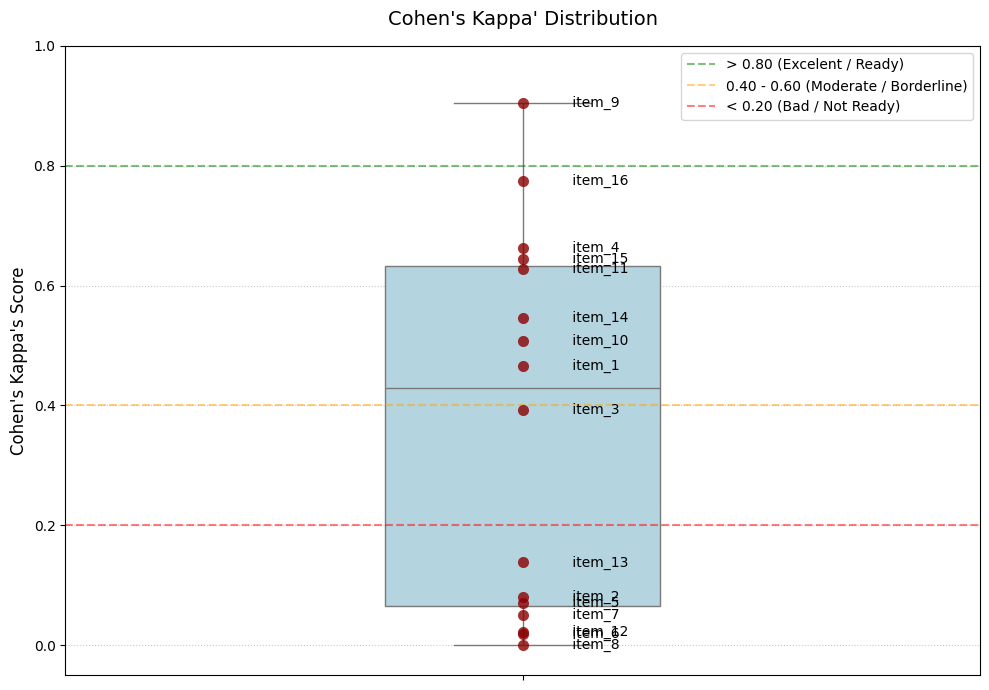

In [13]:
# STEP 2

# Before answering the questions, I will plot a boxplot to show where each item is

# Descriptive Statistics (Quartiles and IQR)
Q1 = df_reliability['kappa'].quantile(0.25)
Q2 = df_reliability['kappa'].median()
Q3 = df_reliability['kappa'].quantile(0.75)
IQR = Q3 - Q1

print(f"--- Boxplot Statistics ---")
print(f"Q1 (Worst 25%): {Q1:.3f}")
print(f"Median: {Q2:.3f}")
print(f"Q3 (Top 25%): {Q3:.3f}\n")

# Ploting the boxplot
plt.figure(figsize=(10, 7))
sns.boxplot(y=df_reliability['kappa'], color='lightblue', width=0.3)
sns.stripplot(y=df_reliability['kappa'], color='darkred', alpha=0.8, size=8, jitter=False)

# Write each item's name
df_sorted = df_reliability.sort_values('kappa').reset_index(drop=True)
for i in range(len(df_sorted)):
    plt.text(0.05, df_sorted['kappa'][i], f" {df_sorted['item'][i]}",
             fontsize=10, va='center', color='black')

# Linhas de referência da literatura de Cohen's Kappa
plt.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='> 0.80 (Excelent / Ready)')
plt.axhline(y=0.4, color='orange', linestyle='--', alpha=0.5, label='0.40 - 0.60 (Moderate / Borderline)')
plt.axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='< 0.20 (Bad / Not Ready)')

plt.title("Cohen's Kappa' Distribution", fontsize=14, pad=15)
plt.ylabel("Cohen's Kappa's Score", fontsize=12)
plt.ylim(-0.05, 1.0)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

## ANSWERS OF TASK 1

Looking for the results, I choose these items:

- **One item you consider ready for operational use**:
I choose the item_9 because it achieved a Cohen’s Kappa of 0.90 alongside a 96.6% absolute agreement rate. In statistics, a Kappa above 0.80 indicates "almost perfect" reliability. This proves the current rubric definition is highly "machine-readable" with strict logical boundaries, resulting in zero significant drift between GPT-4o and GPT-5.1. It is robust enough to be scaled immediately.

- **One item you consider borderline**:
I choose the item_10. It yielded a Cohen’s Kappa of 0.50, placing it squarely in the "Moderate" agreement band (0.41 - 0.60). The models successfully capture the underlying signal better than random chance, but there is still enough ambiguity in edge cases to cause significant disagreement.

- **One item you consider not ready**:
I choose the item_8 as it illustrates the "agreement trap." It has a misleadingly high simple agreement rate of 99.1%, but a Cohen’s Kappa of exactly 0.00. This indicates a severe class imbalance where the models are defaulting to the majority class on autopilot.

--------------------------------------------

### Task 2. Recommended action per item

For each of your three selected items, recommend one of:
- keep as is
- tighten the rubric definition
- treat as not ready for operational use

## ANSWERS OF TASK 2

**Keeps as is**: item_9

**Tighten the rubric definition**: item_10

**Treat as not ready for operational use**: item_8

---

### Task 3. Rewrite two weak rubric items

Select the 2 items you think need the most tightening.

For each, provide:
- A clearer definition
- COUNT ONLY IF (specific conditions)
- DO NOT COUNT (explicit exclusions)
- One example of acceptable evidence from the transcripts

In [14]:
# STEP 1

# I'll take the item_6 and look to where the AI's disagree
disagreements_item6 = df_master[df_master['item_6_answer_gpt4o'] != df_master['item_6_answer_gpt51']]

# First case of disagreement
case_item6 = disagreements_item6.iloc[0]

# Question and the answers of each model
print("QUESTION")
print(case_item6['item_6_question_gpt4o'])

print("\nGPT-4o:", case_item6['item_6_answer_gpt4o'])
print(case_item6['item_6_why_gpt4o'])

print("\nGPT-5.1:", case_item6['item_6_answer_gpt51'])
print(case_item6['item_6_why_gpt51'])

QUESTION
Clarity of Explanation: Effective Modeling Before Expecting Independence In the middle part of the lesson (from ~ minute 25 to minute ~50) did the tutor model the task clearly before expecting students to work independently?

GPT-4o: 0
The tutor did not effectively model tasks before expecting students to work independently.

GPT-5.1: 1
Tutor consistently modeled tasks on screen (platform navigation, file upload, drawing, importing images) before asking students to do them independently.


## ANSWERS OF TASK 3

As you can see, the GPT-5.1 considered that the tutor used the platform, while the GPT-4o did not consider. So, for this item, I will change these things:

**Clearer definition**

Screen sharing must involve an active pedagogical demonstration of a curriculum task. It is the act of showing the students exactly how to perform a learning activity, not simply navigating the computer.

**COUNT ONLY IF**

The tutor shares their screen or software workspace and verbally explains the specific steps of the learning activity being shown to the students.

**DO NOT COUNT**

Screen sharing solely for platform login, adjusting audio/video settings, resolving technical issues, or silent navigation without any pedagogical explanation.

**EXAMPLE OF ACCEPTABLE EVIDENCE**

"Look at my screen. To iterate through this list, we need to write a 'for' loop right here in line 5, and then use the 'print()' function inside the loop to display each item."

In [15]:
# STEP 2

# Now, I'll do the same thing to item_12

# I'll take the item_12 and look to where the AI's disagree
disagreements_item12 = df_master[df_master['item_12_answer_gpt4o'] != df_master['item_12_answer_gpt51']]

# First case of disagreement
case_item12 = disagreements_item12.iloc[0]

# Question and the answers of each model
print("QUESTION")
print(case_item12['item_12_question_gpt4o'])

print("\nGPT-4o:", case_item12['item_12_answer_gpt4o'])
print(case_item12['item_12_why_gpt4o'])

print("\nGPT-5.1:", case_item12['item_12_answer_gpt51'])
print(case_item12['item_12_why_gpt51'])


QUESTION
Content delivery: Did the tutor use the platform (e.g., Kodland) or other visual tools to explain assignments or tasks?

GPT-4o: 0
There is no evidence that the tutor used any platform or visual tools to explain assignments or tasks.

GPT-5.1: 1
Tutor clearly uses a visual platform/screen to present tasks, images, and interactive elements.


## ANSWERS OF TASK 3

As you can see, the GPT-5.1 considered actions like platform navigation, drawing and file upload as model tasks, while the GPT-4o did not consider. So, for this item, I will change these things:

**Clearer definition**

The use of platforms or visual tools must go beyond basic code demonstration. It refers to leveraging visual aids, didactic platforms, or conceptual diagrams to explain abstract concepts or system logic.

**COUNT ONLY IF**

The tutor actively uses a digital whiteboard, presentation slides, a specialized didactic platform (e.g., Kodland platform), or drawing tools to visually map out a concept, logic, or architecture for the student.

**DO NOT COUNT**

Simply sharing an IDE (e.g., VS Code, Jupyter), text editor, or terminal. Using basic software that does not serve a distinct visual/conceptual explanatory purpose.

**EXAMPLE OF ACCETABLE EVIDENCE**

Before we write the code for this function, let me open the whiteboard here to draw a flowchart of how the data will move through our program.

---

## Block 2 — Predictive Usefulness

> Even if a signal is measurable, is it useful for predicting outcomes?

### Task 4. Identify and interpret promising signals

Using the outcomes file:
1. Calculate the relationship between each rubric item and `next_lesson_attended` / `m1_retained`. Show your work.
2. Identify 1–2 items that look most promising. Explain why.

In [16]:
# Obs: I will only use the data of model GPT4o in this task, as it seems with better results

# I will create a DataFrame comparing the retentions of all items when its 0 or 1
results_predictive = []

# Loop to go through the 16 items
for i in range(1, 17):
  col_gpt4o = f'item_{i}_answer_gpt4o'

  rates_m1 = df_master.groupby(col_gpt4o)['m1_retained'].mean()
  rates_nl = df_master.groupby(col_gpt4o)['next_lesson_attended'].mean()

  # Case of m1_retained
  ret_0_m1 = rates_m1.get(0, 0)
  ret_1_m1 = rates_m1.get(1, 0)
  diff_m1 = ret_1_m1 - ret_0_m1

  # Case of next_lesson_attended
  ret_0_nl = rates_nl.get(0, 0)
  ret_1_nl = rates_nl.get(1, 0)
  diff_nl = ret_1_nl - ret_0_nl

  results_predictive.append({
        'item': f'item_{i}',
        'm1_ret_0': ret_0_m1,
        'm1_ret_1': ret_1_m1,
        'm1_diff': diff_m1,
        'm1_abs_diff': abs(diff_m1),
        'nl_att_0': ret_0_nl,
        'nl_att_1': ret_1_nl,
        'nl_diff': diff_nl,
        'nl_abs_diff': abs(diff_nl)
    })

# Creating the DataFrame
df_predictive = pd.DataFrame(results_predictive)
print("=== TOP 5 ITEMS FOR NEXT LESSON ATTENDED ===\n")
print(df_predictive.sort_values(by='nl_abs_diff', ascending=False)[['item', 'nl_att_0', 'nl_att_1', 'nl_diff']].head(5).to_string(index=False))
print("\n\n\n===== TOP 5 ITEMS FOR M1 RETAINED ====\n")
print(df_predictive.sort_values(by='m1_abs_diff', ascending=False)[['item', 'm1_ret_0', 'm1_ret_1', 'm1_diff']].head(5).to_string(index=False))

=== TOP 5 ITEMS FOR NEXT LESSON ATTENDED ===

   item  nl_att_0  nl_att_1  nl_diff
 item_5  0.644444  0.861538 0.217094
 item_3  0.705357  0.921875 0.216518
 item_6  0.654545  0.870270 0.215725
item_12  0.671875  0.875000 0.203125
item_14  0.731707  0.914530 0.182823



===== TOP 5 ITEMS FOR M1 RETAINED ====

   item  m1_ret_0  m1_ret_1   m1_diff
 item_8  0.500000  0.764706  0.264706
 item_3  0.625000  0.882812  0.257812
item_14  0.658537  0.871795  0.213258
item_12  0.671875  0.795455  0.123580
 item_7  0.863636  0.752294 -0.111343


## ANSWERS OF TASK 4

**Describe the approach you used to calculate relationships between rubric items and outcomes**

I used a mean comparison approach via Pandas group-by aggregations to calculate the absolute percentage lift. Specifically, I calculated the average outcome rate (for both next lesson attendance and M1 retention) when a tutor scored 1 versus when they scored 0 on a given item. Crucially, I filtered these results through the Cohen's Kappa scores calculated in Block 1 to exclude items with high variance but low model reliability (e.g., item_5 and item_8). This cross-validation ensures we only rely on signals that are both impactful and "machine-readable".

**Identify 1–2 items that look most promising. Explain why**

item_3 and item_14. Both items demonstrated top-tier percentage lifts across M1 Retention and Next Lesson Attendance. More importantly, they achieved this while strictly passing our reliability threshold (moderate Cohen's Kappa), proving they are not only economically impactful but also genuinely "machine-readable".

**Why does this item look promising for next_lesson_attended?**

After filtering out unreliable items (Kappa < 0.20), item_14 emerged as a highly promising signal. The data shows an 18.2% lift in next lesson attendance: 91.4% of students attended the next lesson when the tutor scored 1, compared to only 73.1% when the tutor scored 0. Combined with its solid moderate Cohen's Kappa (0.54), this makes it a verifiable and safe leading indicator of immediate student engagement.

**Most promising item for predicting m1_retained**

item_3

**Why does this item look promising for m1_retained?**

Item_3 demonstrated a massive +25.7% direct impact on M1 retention. When the tutor scored 1 on this item, the retention rate jumped to 88.2%, compared to a poor baseline of 62.5% when the tutor scored 0. While its Kappa (0.39) is on the borderline of moderate reliability—meaning the prompt will need slight tightening before fully automated scaling—its outsized economic impact on long-term retention makes it the most critical behavioral signal to operationalize.

---

### Task 5. So what?

In 3–5 sentences: if you found 1–2 signals that reliably predict next lesson attendance or M1 retention — what would you actually do with that in practice?

---

## ANSWER OF TASK 5

When AutoQA detects a high volume of 0 scores on highly predictive signals (like item_3 or item_14) across the tutor base, it will route these aggregated insights to the Tutor Development team to build scalable solutions. Instead of unscalable 1-on-1 interventions, this triggers a one-to-many fix workflow—such as automatically enrolling affected cohorts into targeted async training campaigns, updating the global tutor playbook, or implementing real-time pre-class nudges in the platform. Finally, to verify the impact, AutoQA will monitor the cohort's aggregate score improvement and track the subsequent M1 retention lift over the following weeks.